# Классификация текстов с использованием Наивного Байесовского Классификатора

## Задание 1 (1 балл)

Откройте данные. Узнайте, сколько в них спам- и не спам-писем. Визуализируйте полученные соотношение подходящим образом.

In [5]:
import numpy as np
import pandas as pd

email_data = pd.read_csv('spam_or_not_spam.csv', sep=',')
email_data

,email,label
0,date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...,0
1,martin a posted tassos papadopoulos the greek ...,0
2,man threatens explosion in moscow thursday aug...,0
3,klez the virus that won t die already the most...,0
4,in adding cream to spaghetti carbonara which ...,0
...,...,...
2995,abc s good morning america ranks it the NUMBE...,1
2996,hyperlink hyperlink hyperlink let mortgage le...,1
2997,thank you for shopping with us gifts for all ...,1
2998,the famous ebay marketing e course learn to s...,1


In [6]:
email_data.groupby('label').count()

,email
label,
0,2500
1,499


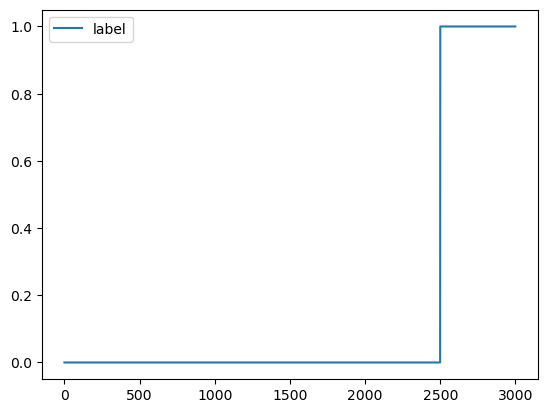

In [38]:
# визуализируйте результат: ваш код здесь
email_data.plot()
data = email_data.copy()

## Задание 2 (2 балла)

Вам необходимо предобработать ваши данные и перевести их в векторный вид. Подгрузим необходимый модуль:

In [68]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import ComplementNB


Замените в данных все пустые строки и строки, состоящие из пробелов, на пропуски (NaN). После этого удалите из данных все строки, в которых наблюдаются пропущенные значения.

In [40]:
#ваш код здесь

# Замена всех пробельных строк на NaN
data = data.replace(r'^\s*$', np.nan, regex=True)

data = data.dropna()

Переводим данные в векторный вид:

In [41]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(data['email'])

Определите, сколько теперь признаков в нашем наборе данных:

In [42]:
#ваш код здесь
#X.shape[1]
X.shape

(2997, 34116)

## Задание 3 (2 балла)

Определите целевую переменную и признаки:

In [43]:
#ваш код здесь

y = data['label']
print(X.shape, y.shape)

(2997, 34116) (2997,)


Разделите выборку на обучающую и тестовую, используя стратифицированное разбиение (параметр `stratify` установите в значение вектора ответов y) размер тестовой выборки (`test_size`) возьмите как 0.25, параметр `random_state` определите со значением 42:

In [44]:
#ваш код здесь
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

Рассчитайте среднее значение целевой переменной по тестовой выборке:

In [51]:
#ваш код здесь
y_test.mean()

0.16533333333333333

## Задание 4 (3 балла)

Определите и обучите подходящий алгоритм с параметром alpha = 0.01

In [66]:
#ваш код здесь

clf = MultinomialNB(alpha = 0.01)
clf.fit(X_train, y_train)

y_test_pred = clf.predict(X_test)

Оцените результат с точки зрения всех известных вам метрик (не менее трёх):

In [78]:
#ваш код здесь

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

print(f"Accuracy: {accuracy_score(y_test, y_test_pred)}")
print(f"Precision: {precision_score(y_test, y_test_pred)}")
print(f"Recall: {recall_score(y_test, y_test_pred)}")

Accuracy: 0.9866666666666667
Precision: 1.0
Recall: 0.9193548387096774


$ Accuracy = \frac{P}{N} = \frac {TP + TN} {TP + TN + FP + FN}$ ,
$ Precision= \frac {TP}{TP+FP}$ ,
$ Recall= \frac {TP}{TP+FN} $


Нарисуйте ROC-кривую:

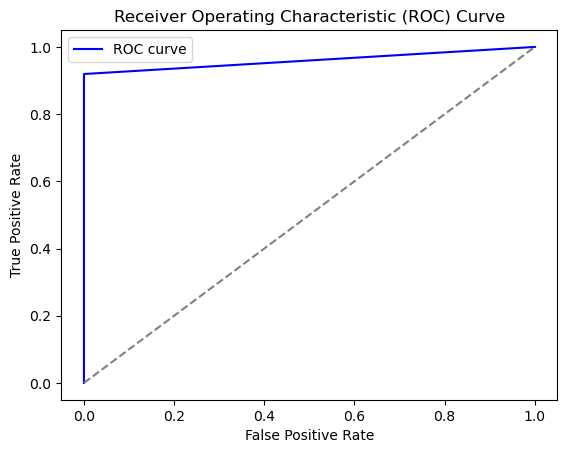

In [87]:
#ваш код здесь

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Вычисление TPR и FPR
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred)

# Построение ROC-кривой
plt.figure()
plt.plot(fpr, tpr, color='blue', label='ROC curve')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

## Задание 5 (3 балла)

Переберите несколько значений alpha с помощью кросс-валидации. Оцените, зависит ли от этого параметра качество классификации.

In [ ]:
#ваш код здесь

In [100]:
from sklearn.model_selection import cross_val_score

In [99]:
clf = MultinomialNB(alpha = 1)
scores = cross_val_score(clf, X, y, cv=5)
scores

array([0.98666667, 0.98166667, 0.97662771, 0.97495826, 0.9933222 ])

In [98]:
clf = MultinomialNB(alpha = 0.1)
scores = cross_val_score(clf, X, y, cv=5)
scores

array([0.98      , 0.97833333, 0.98497496, 0.98163606, 0.98998331])

In [97]:
clf = MultinomialNB(alpha = 0.01)
scores = cross_val_score(clf, X, y, cv=5)
scores

array([0.98666667, 0.98666667, 0.97495826, 0.97495826, 0.98831386])

In [96]:
clf = MultinomialNB(alpha = 0.001)
scores = cross_val_score(clf, X, y, cv=5)
scores

array([0.98666667, 0.98833333, 0.96828047, 0.97495826, 0.98497496])